# Vartotojų žymėjimas ir modelių palyginimas



### Rizikos nustatymas 

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
lof = pd.read_excel("Outputs/lof_results.xlsx")
iforest = pd.read_excel("Outputs/iforest_results.xlsx")

In [37]:
# ============================================================
# 2. LOF – tik įtartini vartotojai
# ============================================================

lof_suspicious = lof[lof["lof_is_anomaly"] == True].copy()

# Kvantiliai
q50_lof = lof_suspicious["lof_score"].quantile(0.50)
q85_lof = lof_suspicious["lof_score"].quantile(0.85)

print("LOF kvantiliai:")
print("Q50:", q50_lof)
print("Q85:", q85_lof)

# Rizikos grupės
def lof_risk(score):
    if score <= q50_lof:
        return "Žema rizika"
    elif score <= q85_lof:
        return "Vidutinė rizika"
    else:
        return "Aukšta rizika"

lof_suspicious["risk_group"] = lof_suspicious["lof_score"].apply(lof_risk)

lof_suspicious.to_excel("Outputs/lof_suspicious_risk_groups.xlsx", index=False)

lof_suspicious

LOF kvantiliai:
Q50: 3.470352404826182
Q85: 9.64643439193456


,account_number,lof_label,lof_is_anomaly,lof_score,risk_group
0,38409b3e16d916bbd96dbb7395a3aa72,-1,True,1.000000e+10,Aukšta rizika
1,5ab264a61e965acc27e0f3ff90b8e4f3,-1,True,2.463737e+09,Aukšta rizika
2,d28aacaa6253a2bdb63f92464126a8c8,-1,True,2.463737e+09,Aukšta rizika
3,84e7d8b4bec578140a771b88fe6fbf50,-1,True,2.463737e+09,Aukšta rizika
4,913b0822948173940ff6b11eb998dbaa,-1,True,1.912365e+09,Aukšta rizika
...,...,...,...,...,...
92,97a68845f6557cf7464c1c913d028069,-1,True,2.537799e+00,Žema rizika
93,c2174c572dfcc9fdf9a1b18bf302ed3c,-1,True,2.532711e+00,Žema rizika
94,29bc5c34cdb5c32048f3dc7ecdf5859f,-1,True,2.523279e+00,Žema rizika
95,614270724639440a58bea36cc09d52f9,-1,True,2.445917e+00,Žema rizika


In [38]:
# ============================================================
# 3. Isolation Forest – tik įtartini vartotojai
# ============================================================

iforest_suspicious = iforest[iforest["iforest_is_anomaly"] == 1].copy()

# Kvantiliai
q50_if = iforest_suspicious["iforest_anomaly_score"].quantile(0.50)
q85_if = iforest_suspicious["iforest_anomaly_score"].quantile(0.85)

print("\niForest kvantiliai:")
print("Q50:", q50_if)
print("Q85:", q85_if)

# Rizikos grupės
def iforest_risk(score):
    if score <= q50_if:
        return "Žema rizika"
    elif score <= q85_if:
        return "Vidutinė rizika"
    else:
        return "Aukšta rizika"

iforest_suspicious["risk_group"] = iforest_suspicious["iforest_anomaly_score"].apply(iforest_risk)

iforest_suspicious.to_excel("Outputs/iforest_suspicious_risk_groups.xlsx", index=False)

iforest_suspicious


iForest kvantiliai:
Q50: 0.7026898026897016
Q85: 0.7554292437003128


,account_number,iforest_prediction,iforest_anomaly_score,iforest_is_anomaly,risk_group
102,02fd177ff43e28b012e98c1e7fe5a002,-1,0.746592,1,Vidutinė rizika
213,06090a2f32120d254b6bb95d53f10786,-1,0.665397,1,Žema rizika
255,0760c6e3d4f363f6816633283ae537f1,-1,0.674020,1,Žema rizika
261,07781e8d394369feab90c88842f472d3,-1,0.760307,1,Aukšta rizika
420,0b961f3236e57b42c3c5f6a2893d1b01,-1,0.700471,1,Žema rizika
...,...,...,...,...,...
9179,f5200c4b7a90b38090e2cec03a4568a2,-1,0.699628,1,Žema rizika
9210,f5e7a215add1430e9bb32b7a96df405f,-1,0.702690,1,Žema rizika
9266,f74803df15deafa94643360a4a00bd22,-1,0.752183,1,Vidutinė rizika
9323,f87dc865abdfe6d1ea55e722782dab60,-1,0.677116,1,Žema rizika


In [39]:
# ============================================================
# 4. Pasiskirstymas
# ============================================================

print("\nLOF rizikos grupės:")
print(lof_suspicious["risk_group"].value_counts())

print("\niForest rizikos grupės:")
print(iforest_suspicious["risk_group"].value_counts())



LOF rizikos grupės:
risk_group
Žema rizika        49
Vidutinė rizika    34
Aukšta rizika      14
Name: count, dtype: int64

iForest rizikos grupės:
risk_group
Žema rizika        49
Vidutinė rizika    33
Aukšta rizika      15
Name: count, dtype: int64


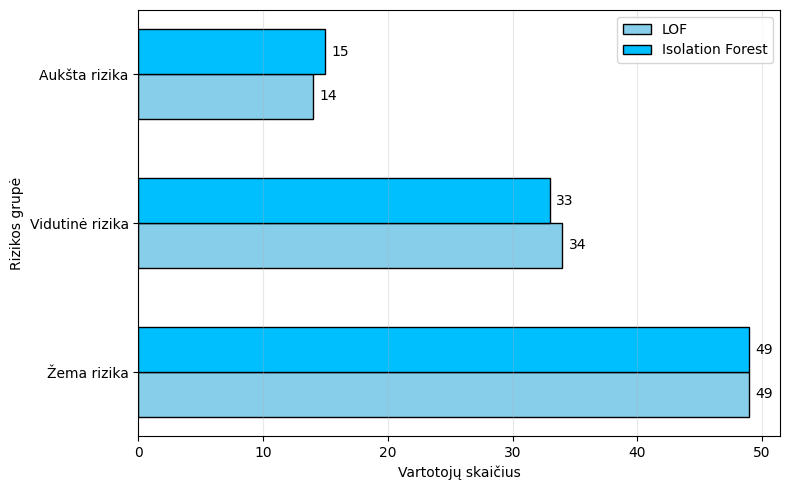

In [40]:
# ============================================================
# 5. Vizualizacija
# ============================================================

lof_counts = lof_suspicious["risk_group"].value_counts()
iforest_counts = iforest_suspicious["risk_group"].value_counts()

order = ["Žema rizika", "Vidutinė rizika", "Aukšta rizika"]
y = np.arange(len(order))
height = 0.3

plt.figure(figsize=(8, 5))

plt.barh(y - height/2, lof_counts.values, height, label="LOF", color='skyblue', edgecolor='black')
plt.barh(y + height/2, iforest_counts.values, height, label="Isolation Forest", color='deepskyblue', edgecolor='black')

plt.yticks(y, order)
plt.xlabel("Vartotojų skaičius")
plt.ylabel("Rizikos grupė")
# plt.title("LOF ir Isolation Forest rizikos grupių pasiskirstymo palyginimas")
plt.legend()
plt.grid(axis="x", alpha=0.3)

# Skaičiai ant stulpelių
for i, v in enumerate(lof_counts.values):
    plt.text(v + 0.5, y[i] - height/2, str(v), va="center")

for i, v in enumerate(iforest_counts.values):
    plt.text(v + 0.5, y[i] + height/2, str(v), va="center")

plt.tight_layout()
plt.show()

### Metodų / rezultatų palyginimas

In [41]:
# LOF anomalijos
lof_anomalies = set(lof_suspicious["account_number"])

# iForest anomalijos
iforest_anomalies = set(iforest_suspicious["account_number"])

In [52]:
# Jaccard koeficientas

intersection = lof_anomalies & iforest_anomalies
union = lof_anomalies | iforest_anomalies

jaccard = len(intersection) / len(union)

print("Jaccard koeficientas:", round(jaccard, 4))

Jaccard koeficientas: 0.0543


In [43]:
print("\nStatistika:")

print("LOF anomalijų skaičius:", len(lof_anomalies))
print("iForest anomalijų skaičius:", len(iforest_anomalies))

print("Bendros anomalijos:", len(intersection))

print("Tik LOF:", len(lof_anomalies - iforest_anomalies))
print("Tik iForest:", len(iforest_anomalies - lof_anomalies))

overlap_iforest = len(intersection) / len(iforest_anomalies) * 100
print(f"Procentinis sutapimas: {overlap_iforest:.2f}%")


Statistika:
LOF anomalijų skaičius: 97
iForest anomalijų skaičius: 97
Bendros anomalijos: 10
Tik LOF: 87
Tik iForest: 87
Procentinis sutapimas: 10.31%


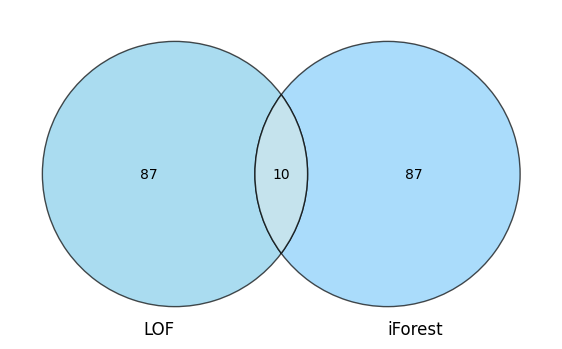

In [44]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

plt.figure(figsize=(7, 6))

venn =venn2(
    subsets=(
        len(lof_anomalies - iforest_anomalies),   # Tik LOF
        len(iforest_anomalies - lof_anomalies),   # Tik iForest
        len(lof_anomalies & iforest_anomalies)    # Abu metodai
    ),
    set_labels=("LOF", "iForest")
)

# Spalvos (mėlyni atspalviai)
venn.get_patch_by_id('10').set_color('skyblue')  # LOF (šviesesnė mėlyna)
venn.get_patch_by_id('01').set_color('lightskyblue')  # iForest (tamsesnė mėlyna)
venn.get_patch_by_id('11').set_color('lightblue')  # Persidengimas (vidutinė)

# Skaidrumas
for patch in ['10', '01', '11']:
    venn.get_patch_by_id(patch).set_alpha(0.7)

# Juodas outline
for patch in ['10', '01', '11']:
    p = venn.get_patch_by_id(patch)
    if p:
        p.set_edgecolor('black')
        # p.set_linewidth(2)

# plt.title("LOF ir iForest aptiktų anomalijų sutapimas")
plt.show()

### Persidengimo analizė tikrinant rizikos grupes

In [53]:
common_accounts = list(intersection)

lof_common = lof_suspicious.loc[
    lof_suspicious["account_number"].isin(common_accounts),
    ["account_number", "lof_score", "risk_group"]
].rename(columns={"risk_group": "lof_risk"})

iforest_common = iforest_suspicious.loc[
    iforest_suspicious["account_number"].isin(common_accounts),
    ["account_number", "iforest_anomaly_score", "risk_group"]
].rename(columns={"risk_group": "iforest_risk"})

common_risks = pd.merge(
    lof_common,
    iforest_common,
    on="account_number",
    how="inner"
).sort_values("account_number").reset_index(drop=True)

common_risks.to_excel("Outputs/common_risks.xlsx", index=False)

common_risks

,account_number,lof_score,lof_risk,iforest_anomaly_score,iforest_risk
0,02fd177ff43e28b012e98c1e7fe5a002,5.698948,Vidutinė rizika,0.746592,Vidutinė rizika
1,2811e96ccdaa4c81a9fa3017c430a228,2.620160,Žema rizika,0.682570,Žema rizika
2,2c8cff0439be4b658554998c3cd29785,92.445980,Aukšta rizika,0.778591,Aukšta rizika
3,461290100f21ca2b1af653cc03776f5d,11.781552,Aukšta rizika,0.773502,Aukšta rizika
4,59a47e8de57675065f70c44deefd42c2,2.931824,Žema rizika,0.667347,Žema rizika
5,7b0ac7555cbd3c781574dbf8f1dd300a,4.646698,Vidutinė rizika,0.677571,Žema rizika
6,8b9cbe6cf4a3f8d43123178fecacc040,7.583967,Vidutinė rizika,0.773985,Aukšta rizika
7,b286e6d78c581434fc689fb538f5a29c,3.744525,Vidutinė rizika,0.734022,Vidutinė rizika
8,b6fee32818e3b530291a7176177a2c67,6.266792,Vidutinė rizika,0.751895,Vidutinė rizika
9,d7afdb5f0ad3dac2f5fcd366bb545fe4,3.156219,Žema rizika,0.714827,Vidutinė rizika


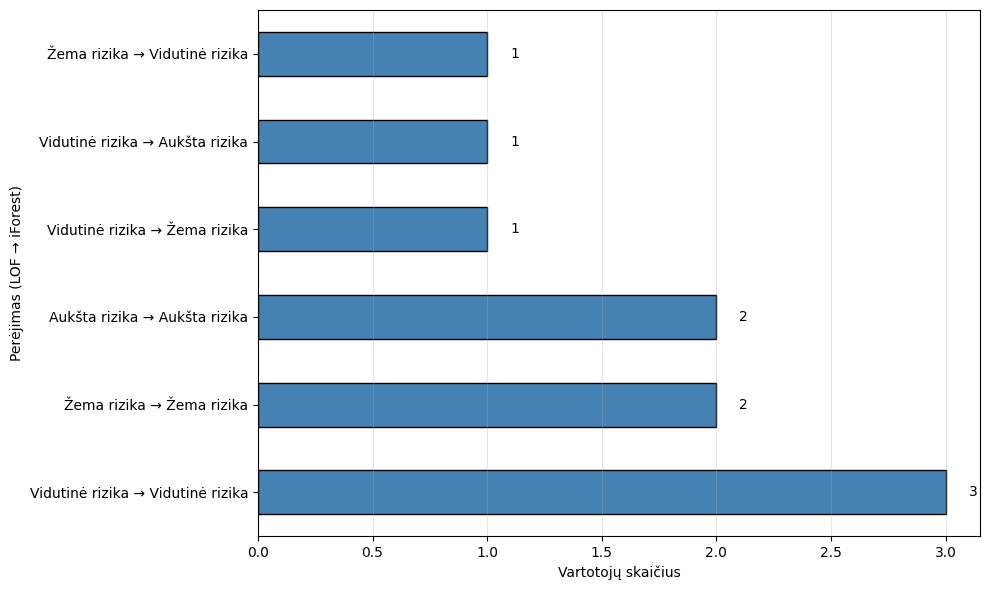

In [46]:
comparison = common_risks.copy()
comparison["transition"] = comparison["lof_risk"] + " → " + comparison["iforest_risk"]

transition_counts = comparison["transition"].value_counts()

plt.figure(figsize=(10, 6))

transition_counts.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

# plt.title("Rizikos grupių pokyčiai tarp LOF ir iForest")
plt.xlabel("Vartotojų skaičius")
plt.ylabel("Perėjimas (LOF → iForest)")
plt.grid(axis="x", alpha=0.3)

# skaičiai ant barų
for i, v in enumerate(transition_counts):
    plt.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

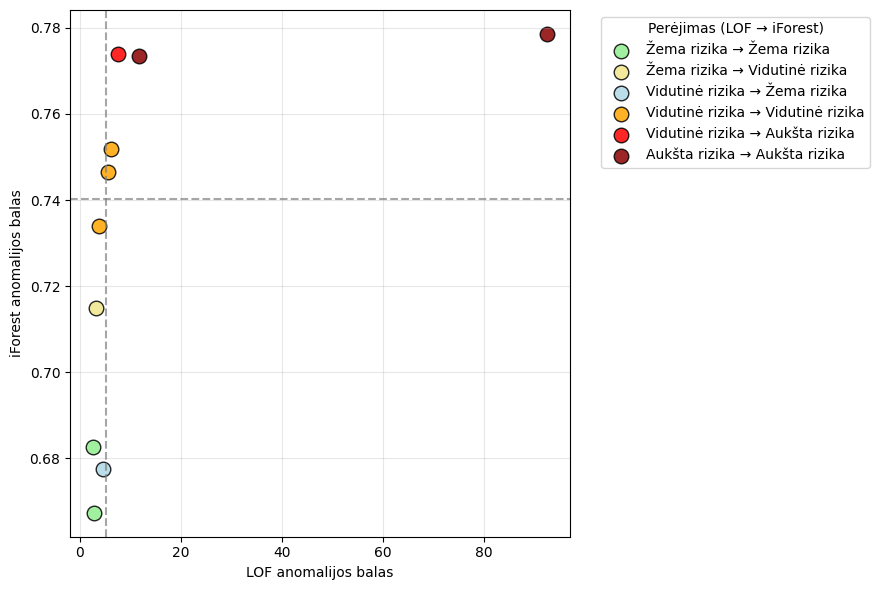

In [54]:
import matplotlib.pyplot as plt

# Sukuriame perėjimo stulpelį: LOF → iForest
common_risks["transition"] = common_risks["lof_risk"] + " → " + common_risks["iforest_risk"]

# Spalvos pagal perėjimus
transition_colors = {
    "Žema rizika → Žema rizika": "lightgreen",
    "Žema rizika → Vidutinė rizika": "khaki",
    "Žema rizika → Aukšta rizika": "lightcoral",
    "Vidutinė rizika → Žema rizika": "lightblue",
    "Vidutinė rizika → Vidutinė rizika": "orange",
    "Vidutinė rizika → Aukšta rizika": "red",
    "Aukšta rizika → Žema rizika": "purple",
    "Aukšta rizika → Vidutinė rizika": "violet",
    "Aukšta rizika → Aukšta rizika": "darkred"
}

fig, ax = plt.subplots(figsize=(9, 6))

for transition, color in transition_colors.items():
    subset = common_risks[common_risks["transition"] == transition]
    
    if len(subset) > 0:
        ax.scatter(
            subset["lof_score"],
            subset["iforest_anomaly_score"],
            label=transition,
            color=color,
            edgecolor="black",
            s=110,
            alpha=0.85
        )

# ax.set_title("LOF ir iForest anomalijų balų palyginimas pagal rizikos perėjimus")
ax.set_xlabel("LOF anomalijos balas")
ax.set_ylabel("iForest anomalijos balas")
ax.grid(alpha=0.3)

# --- svarbus pagerinimas ---
# pridedam vidurio linijas (padeda interpretuoti)
ax.axvline(common_risks["lof_score"].median(), linestyle="--", color="gray", alpha=0.7)
ax.axhline(common_risks["iforest_anomaly_score"].median(), linestyle="--", color="gray", alpha=0.7)


ax.legend(
    title="Perėjimas (LOF → iForest)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()